In [1]:
import torch
from torch.utils.data import DataLoader
import os
from datasets import load_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer
from transformers import LlamaForCausalLM, LlamaTokenizerFast
import transformers

from torch import nn
from torch import optim

from torch.utils.tensorboard import SummaryWriter

from datasets import load_dataset
import pickle

## Loading the model

In [2]:
torch. set_grad_enabled(False) 
tokenizer = AutoTokenizer.from_pretrained('google/gemma-7b')
# gemma7 = AutoModelForCausalLM.from_pretrained('google/gemma-7b', torch_dtype=torch.float16,device_map="auto")

In [3]:
# torch. set_grad_enabled(False) 
# gemma7 = AutoModelForCausalLM.from_pretrained('google/gemma-7b', torch_dtype=torch.float16,device_map="cuda:0")
rank = 0
device = f'cuda:{rank}'
gemma2 = AutoModelForCausalLM.from_pretrained('google/gemma-2b', torch_dtype=torch.float16,device_map=device)


Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
torch.cuda.synchronize()
torch.cuda.empty_cache()
torch.cuda.synchronize()

## Loading Data

In [5]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, data, tokenizer):
        global paths
        global epoch
        self.data = data
        self.tokenizer = tokenizer
    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        line=self.data[i]['text'][0:8000]
        batch  = self.tokenizer(line, max_length=1025, padding='max_length', truncation=True)
        batch  = self.tokenizer(line, max_length=1025, padding='max_length', truncation=True)
        batch['input_ids']=torch.tensor(batch['input_ids'])
        return batch


sentence = big_texts[1014]['text']
t1 = time.time()
tokenizer(sentence, max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)
t1 = time.time()
tokenizer(sentence[:5000], max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)
t1 = time.time()
tokenizer(sentence[:6000], max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)
t1 = time.time()
tokenizer(sentence[:7000], max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)
t1 = time.time()
tokenizer(sentence[:8000], max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)



In [6]:
import datasets

In [7]:
texts = datasets.load_from_disk('~/.cache/huggingface/datasets/filtered-math')

Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

In [8]:
dataset = Dataset(texts, tokenizer)

## Storing the matrices

In [9]:
import gc
import io 
class quantizer_4b_torch:   
    def quantize(self,a): # it is assumed that the distribution of the values is normal
        is_negative=torch.sign(a)<0
        
        x=torch.sqrt(torch.abs(a))*5.3-2.1
        x=torch.round(x)
        x=torch.clip(x,0,7).to(torch.int8)
        
        x=x+8*is_negative.to(torch.int8)
        return x
    
    def decode(self,x):
        is_negative=x>=8
        a=(( torch.remainder(x,8).to(torch.float16)+2.1)/5.3)**2
        a=a*(1-is_negative.to(torch.int8)*2)
        return a
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::2]*16+ind[:,1::2]
        return comp.to(torch.uint8)

    def load_decode(self,data):
        ind=torch.zeros((data.shape[0],data.shape[1]*2),dtype=torch.uint8,device=data.device)
        ind[:,0::2]=torch.floor_divide(data,16)
        ind[:,1::2]=torch.remainder(data,16)
        return self.decode(ind)

class representation_whitening_torch:
    def fit(self,a):
        self.mn=a.mean(dim=0)
        
        # low memory covariance calculation
        cov=torch.eye(a.shape[1],dtype=torch.float32,device=a.device)*0
        for i in range(0,a.shape[0],10000):
            aslice=(a[i:i+10000,:].to(torch.float32)-self.mn)
            cov+=( aslice.T@aslice)/a.shape[0]
        
        
        s2,self.q=torch.linalg.eigh(cov)
        self.q=self.q.to(torch.float16)
        self.s=torch.sqrt(s2).to(torch.float16)
        
        if self.s[0]<self.s[-1]:
            self.s=torch.flip(self.s,dims=[0])
            self.q=torch.flip(self.q,dims=[1])
       
    def encode(self,a):
        return (a-self.mn)@self.q /self.s
    
    def decode(self,e):
        return (self.s*e)@self.q.T+self.mn
    
    def rescale(self,e):
        return self.s*e
    
    def save_state_dict(self,path):
        torch.save({'mn':self.mn,'q':self.q,'s':self.s}, path)

    def load_state_dict(self,path):
        data=torch.load(path)
        self.mn=data['mn']
        self.q =data['q' ]
        self.s =data['s' ]
W = representation_whitening_torch()
W.load_state_dict("wtorch.pth")
W.mn = W.mn.to(gemma2.device)
W.q = W.q.to(gemma2.device)
W.s = W.s.to(gemma2.device)
q4 = quantizer_4b_torch()

LOCATION = "/igli/raw_logits_v2"
def generate_confusion_data(model, dataset, nfiles = 1000, nbatches = 1000, batch_size = 4, top_k = 100, max_length = 1024, file_start = 0):
    with torch.no_grad():
        file_no = file_start 
        dataset = dataset.select(range(file_no * nbatches * batch_size, len(big_texts)))
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
        loop=tqdm(loader, leave=True)
        
        # Ground Truth IDs
        ID   = torch.zeros((nbatches*batch_size, max_length)).type(torch.int32).to(device=model.device)
        # Teacher Logits
        TL = torch.zeros((nbatches*batch_size, max_length, top_k)).type(torch.float16).to(device=model.device)
        # Teacher IDs
        T_ID   = torch.zeros((nbatches*batch_size, max_length, top_k)).type(torch.int32).to(device=model.device)

        for (i,batch) in enumerate(loop):
            if i > 0 and i % nbatches == 0:
                ID.cpu().detach().numpy().tofile(os.path.join(LOCATION,f"{file_no:04d}_id_gt"))
                T_ID.cpu().detach().numpy().tofile(os.path.join(LOCATION,f"{file_no:04d}_id_t"))
                TL.cpu().detach().numpy().tofile(os.path.join(LOCATION,f"{file_no:04d}_logit_t"))

                file_no += 1

                ID   = torch.zeros((nbatches*batch_size, max_length)).type(torch.int32).to(device=model.device)
                TL   = torch.zeros((nbatches*batch_size, max_length, top_k)).type(torch.float16).to(device=model.device)
                T_ID = torch.zeros((nbatches*batch_size, max_length, top_k)).type(torch.int32).to(device=model.device)
                torch.cuda.empty_cache()
                torch.cuda.synchronize()

            i = i % nbatches
            labels = batch['input_ids'][..., 1:].clone().detach()
            input_ids      = batch['input_ids'].to(model.device)
            output=model.forward(input_ids,return_dict=True,use_cache=False,output_hidden_states=False)

            logits = output['logits'][..., :-1, :]
            sort_results = torch.topk(logits, top_k, dim=-1).indices
            ID  [i*batch_size : (i+1)*batch_size] = labels
            T_ID[i*batch_size : (i+1)*batch_size] = sort_results
            TL  [i*batch_size : (i+1)*batch_size] = logits[torch.arange(batch_size).reshape(batch_size,1,1), torch.arange(max_length).reshape(1,max_length,1), sort_results]

def generate_student_data(student_model, nfiles, minibatch_size=6):
    embedding_size = student_model.lm_head.in_features
    for file_no in tqdm(range(nfiles)):
        ID   = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_id_gt"), dtype=np.int32)).reshape( 1/0 ) # Fill in the correct shape here .reshape(1000, 1024)
        T_ID = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_id_t"), dtype=np.int32)).reshape( 1/0 )  # Fill in the correct shape here .reshape(1000, 1024, 100)       
        TL   = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_logit_t"), dtype=np.float16)).reshape( 1/0 ) # Fill in the correct shape  .reshape(1000, 1024, 100)
        
        # Student Logits
        SL = torch.zeros_like(TL, device=student_model.device)
        # Student Embeddings
        SE = torch.zeros((SL.size(0), SL.size(1), embedding_size), device=student_model.device, dtype=torch.float16)
        
        batch_size = ID.size(0) # This is old_batch_size
        max_length = ID.size(1)

        start_tokens = torch.tensor(2, dtype=torch.int32).to(student_model.device).repeat(batch_size, 1)
        input_ids = torch.concatenate((start_tokens, ID), dim=1).to(student_model.device)

        # TODO: Loop through minibatches here if memory fails
        # minibatch_size = 16
        for minibatch in tqdm(range(0, batch_size, minibatch_size)):
            next_limit = min(minibatch+minibatch_size, batch_size)
            embeddings = student_model.model(input_ids[minibatch:next_limit], return_dict=True,use_cache=False,output_hidden_states=False)['last_hidden_state']
            output = student_model.lm_head(embeddings)[..., :-1, :]
            embeddings = embeddings[..., :-1, :]
            
            SL[minibatch : next_limit] = output[torch.arange(next_limit-minibatch).reshape(next_limit-minibatch,1,1), torch.arange(max_length).reshape(1,max_length,1), T_ID[minibatch:next_limit]]
            SE[minibatch : next_limit] = embeddings
        SL.cpu().detach().numpy().tofile(os.path.join(LOCATION, f"{file_no:04d}_logit_s"))
        SE.cpu().detach().numpy().tofile(os.path.join(LOCATION,f"{file_no:04d}_emb_s"))
        
        del SL
        del SE
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        gc.collect()

def generate_student_experiment_data(student_model, tokens_of_interest, nfiles, start_file=0, minibatch_size=6):
    for file_no in tqdm(range(start_file, nfiles)):
        file_mapper = {
            token_id:[
                open(os.path.join(LOCATION, f'{file_no:04d}_{token_id}_index_new'), 'ba'), 
                open(os.path.join(LOCATION, f'{file_no:04d}_{token_id}_student_embeddings_new'), 'ba'),
                open(os.path.join(LOCATION, f'{file_no:04d}_{token_id}_student_logits_new'), 'ba'),
                open(os.path.join(LOCATION, f'{file_no:04d}_{token_id}_student_probs_new'), 'ba')
            ] for token_id in tokens_of_interest}
        
        ID   = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_id_gt"), dtype=np.int32), device=student_model.device).reshape(1000, 1024)
        T_ID = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_id_t"), dtype=np.int32), device='cpu').reshape(1000, 1024, 100)
        
        batch_size = ID.size(0) # This is old_batch_size
        max_length = ID.size(1)

        start_tokens = torch.tensor(2, dtype=torch.int32).to(student_model.device).repeat(batch_size, 1)
        input_ids = torch.concatenate((start_tokens, ID), dim=1).to(student_model.device)

        for minibatch in tqdm(range(0, batch_size, minibatch_size)):
            next_limit = min(minibatch+minibatch_size, batch_size)
            embeddings = student_model.model(input_ids[minibatch:next_limit], return_dict=True,use_cache=False,output_hidden_states=False)['last_hidden_state']
            output = student_model.lm_head(embeddings)[..., :-1, :]
            embeddings = embeddings[..., :-1, :]
            # Populating the files
            for token_id in tokens_of_interest:
                index_file, embs_file, student_logits_file, student_probs_file = file_mapper[token_id][0], file_mapper[token_id][1], file_mapper[token_id][2], file_mapper[token_id][3]
                ind = torch.logical_or((ID[minibatch:next_limit] == token_id).cpu(), (T_ID[minibatch:next_limit, :, :10] == token_id).any(dim=-1)).nonzero()
                embeddings[ind[:,0], ind[:,1]].cpu().detach().numpy().astype('float16').tofile(embs_file)
                
                output[ind[:, 0].reshape(-1, 1), ind[:, 1].reshape(-1, 1), T_ID[minibatch:next_limit][ind[:,0], ind[:,1]]].cpu().detach().numpy().astype('float16').tofile(student_logits_file)
                torch.softmax(output, dim=-1)[ind[:, 0].reshape(-1, 1), ind[:, 1].reshape(-1, 1), T_ID[minibatch:next_limit][ind[:,0], ind[:,1]]].cpu().detach().numpy().astype('float16').tofile(student_probs_file)
                ind[:,0] += minibatch
                
                ind.cpu().detach().numpy().astype('int16').tofile(index_file)
                ind = ind.cpu()
        # for k in file_mapper:
        #     file_mapper[k][0].close()
        #     file_mapper[k][1].close()
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        gc.collect()

def v3student(student_model, tokens_of_interest, nfiles, start_file, rank, minibatch_size=8):
    for file_no in range(4*start_file+rank, nfiles, 4):
        ID   = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_id_gt"), dtype=np.int32), device=student_model.device).reshape(1000, 1024)
        T_ID = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_id_t"), dtype=np.int32), device='cpu').reshape(1000, 1024, 100)
        
        index_file = open(os.path.join(LOCATION, f'{file_no:04d}_student_index_new'), 'ba')
        embs_file = open(os.path.join(LOCATION, f'{file_no:04d}_student_embeddings_new'), 'ba')
        student_probs_file = open(os.path.join(LOCATION, f'{file_no:04d}_student_probs_new'), 'ba')
        
        batch_size = ID.size(0) # This is old_batch_size
        max_length = ID.size(1)

        start_tokens = torch.tensor(2, dtype=torch.int32).to(student_model.device).repeat(batch_size, 1)
        input_ids = torch.concatenate((start_tokens, ID), dim=1).to(student_model.device)

        for minibatch in tqdm(range(0, batch_size, minibatch_size)):
            next_limit = min(minibatch+minibatch_size, batch_size)
            embeddings = student_model.model(input_ids[minibatch:next_limit], return_dict=True,use_cache=False,output_hidden_states=False)['last_hidden_state']
            output = student_model.lm_head(embeddings)[..., :-1, :]
            embeddings = embeddings[..., :-1, :]
            # Populating the files
            ind = torch.logical_or(
                torch.isin(ID[minibatch:next_limit].cpu(), tokens_of_interest), 
                torch.isin(T_ID[minibatch:next_limit, :, :10], tokens_of_interest).any(dim=-1)
                ).nonzero()
            
            # TODO: Quantize these   
            embs = W.encode(embeddings[ind[:,0], ind[:,1]])
            quantized = q4.quantize_compress(embs)
            quantized.cpu().detach().numpy().tofile(embs_file)
            
            torch.softmax(output, dim=-1)[ind[:, 0].reshape(-1, 1), ind[:, 1].reshape(-1, 1), T_ID[minibatch:next_limit][ind[:,0], ind[:,1]]].cpu().detach().numpy().astype('float16').tofile(student_probs_file)
            ind[:,0] += minibatch
            
            ind.cpu().detach().numpy().astype('int16').tofile(index_file)
            ind = ind.cpu()


In [10]:
def get_tokens_of_interest(nfiles=2662):
    COUNTS = np.zeros(256000, dtype=np.int32)
    LOCATION = '/igli/raw_logits_v2'
    for file_no in tqdm(range(nfiles)):
        id = np.fromfile(os.path.join(LOCATION,f"{file_no:04d}_id_gt"),  dtype=np.int32)
        unique, counts = np.unique(id, return_counts=True)
        COUNTS[unique] += counts
    return np.argsort(-COUNTS)[:10000]

# tokens_of_interest = get_tokens_of_interest()
tokens_of_interest = torch.tensor(np.fromfile('tokens_of_interest', dtype=np.int32))

In [11]:
v3student(gemma2, tokens_of_interest, 2662, 85, rank, 8)

 25%|██▍       | 31/125 [00:58<02:31,  1.61s/it]

In [ ]:
85

import threading, os, torch
def binarize16(files):
    for filename in files:
        print(filename)
        try:
            t = torch.load(filename, map_location='cpu')
            t = t.detach().numpy().astype(np.float16).tofile(filename)
        except:
            print("Error in", filename)

def start_threads(n):
    LOCATION = "/media/igli/c8d7d852-a9fd-4353-be47-000a0fe82201/raw_logits"

    files = [os.path.join(LOCATION,f"{file_no:04d}_emb_s") for file_no in range(4, n-1)]
    binarize16(files)
start_threads(29)

In [12]:
generate_confusion_data(gemma7, dataset, nbatches=500, nfiles=500, batch_size=2)

100%|█████████████████████████████| 1331902/1331902 [236:42:56<00:00,  1.56it/s]


## Combined model inference

In [2]:
class Node:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.prev = None
        self.next = None

class LRUCache:
    def __init__(self, capacity):
        self.capacity = capacity
        self.cache = {}
        self.head = Node(0, 0)
        self.tail = Node(0, 0)
        self.head.next = self.tail
        self.tail.prev = self.head

    def _add_node(self, node):
        node.prev = self.head
        node.next = self.head.next
        self.head.next.prev = node
        self.head.next = node

    def _remove_node(self, node):
        prev = node.prev
        new = node.next
        prev.next = new
        new.prev = prev

    def _move_to_head(self, node):
        self._remove_node(node)
        self._add_node(node)

    def get(self, key):
        if key in self.cache:
            node = self.cache[key]
            self._move_to_head(node)
            return node.value
        return -1

    def put(self, key, value):
        if key in self.cache:
            node = self.cache[key]
            node.value = value
            self._move_to_head(node)
        else:
            new_node = Node(key, value)
            self.cache[key] = new_node
            self._add_node(new_node)
            
            if len(self.cache) > self.capacity:
                lru = self.tail.prev
                self._remove_node(lru)
                del self.cache[lru.key]

In [ ]:
class FilteredRefiner(torch.nn.Module):
    def __init__(self, models_path, device):
        self.models_path= models_path
        self.bigmodels  = load_big_models(models_path, device)
        self.smallmodels= load_small_models(models_path, device)
        self.big_weights = torch.concatenate((model.linear1.weight for model in self.bigmodels), dim=0).reshape(-1, 64, 2048)
        self.big_bias = torch.concatenate((model.linear1.bias for model in self.bigmodels), dim=0).reshape(-1, 64, 1)
        self.small_weights = torch.concatenate((model.linear1.weight for model in self.smallmodels), dim=0).reshape(-1, 8, 2048)
        self.small_bias = torch.concatenate((model.linear1.bias for model in self.smallmodels), dim=0).reshape(-1, 8, 1)
        self.normalization_factor = torch.sqrt(torch.tensor(2048))

    # Assumes that for each batch element, the filters have the same size :(( 
    def forward(self, x, big_filter, small_filter, student_probs, teacher_probs=None, weight=None):
        combined_weights = torch.concatenate((self.big_weights[big_filter].reshape(-1, 2048), self.small_weights[small_filter].reshape(-1, 2048)), dim=0)
        combined_bias = torch.concatenate((self.big_bias[big_filter].reshape(-1, 1), self.small_bias[small_filter].reshape(-1, 1)), dim=0)
        combined_out = torch.nn.functional.relu(torch.nn.functional.linear(x.float(), combined_weight, combined_bias)) / self.normalization_factor
        
        big_1 = combined_out[:,:64*len(big_filter)].reshape(x.shape[0],len(big_filter),64).sum(dim=-1) 
        small_1 = combined_out[:, 64*len(big_filter):].reshape(x.shape[0], len(small_filter),8).sum(dim=-1)
        combined_1 = torch.concatenate((big_1, small_1), dim=1)
        combined_2 = combined_1 + student_probs
        combined_3 = torch.clip(combined_2, 0, configuration['residual_scaler'])
        
        return combined_3
        
class CombinedModel(torch.nn.Module):
    def __init__(self, models_path, device, refine_topk=10):
        from transformers import AutoModelForCausalLM
        self.path = models_path
        self.refine_topk = refine_topk
        self.device = device
        self.backbone = AutoModelForCausalLM.from_pretrained('google/gemma-2b', torch_dtype=torch.float16,device_map=self.device)
        # self.cached_parameters = LRUCache(cache_size)
        self.large_parameters = self._load_refiners_params(self.models_path)
        self.refineable_ids = torch.tensor(np.fromfile('tokens_of_interest', dtype=np.int32), device=self.device)
        self.parallel_refiner = FilteredRefiner(self.models_path, self.device)
        
    def forward(self, x):
        embeddings = self.backbone.model(x, return_dict=True,use_cache=False,output_hidden_states=False)['last_hidden_state'][..., -1, ...]
        output = torch.softmax(self.backbone.lm_head(embeddings), dim=-1)
        torefine = torch.topk(output, self.refine_topk, dim=-1).indices
        large_model_mask = torch.isin(self.refineable_ids[:1000], torefine)
        small_model_mask = torch.isin(self.refineable_ids[1000:], torefine)
        student_probs = output[:, [*large_model_mask.nonzero(), *small_model_mask.nonzero()]]
        new_probs = self.parallel_refiner(x, large_model_mask, small_model_mask, student_probs)
        output[:, [*large_model_mask.nonzero(), *small_model_mask.nonzero()]] = new_probs
        output = output / output.sum(dim=-1, keepdims=True)
        return output

## Fixing the Student probabilities

In [15]:
torch.cuda.empty_cache()
torch.cuda.synchronize()


In [14]:
gemma2 = gemma2.to('cuda:3')

In [8]:
ID   = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{0:04d}_id_gt"), dtype=np.int32), device=gemma2.device).reshape(1000, 1024)
minibatch_size = 100
batch_size = ID.size(0) # This is old_batch_size
max_length = ID.size(1)

start_tokens = torch.tensor(2, dtype=torch.int32).to(gemma2.device).repeat(batch_size, 1)
input_ids = torch.concatenate((start_tokens, ID), dim=1).to(gemma2.device)
import time
t1 = time.time()
for minibatch in tqdm(range(0, batch_size, minibatch_size)):
    next_limit = min(minibatch+minibatch_size, batch_size)
    embeddings = gemma2.model(input_ids[minibatch:next_limit], return_dict=True,use_cache=False,output_hidden_states=False)['last_hidden_state']
t2 = time.time()


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:55<00:00,  5.52s/it]


In [9]:
len(list(range(0, batch_size, minibatch_size)))

167

In [7]:
t2-t1

61.03455638885498

In [ ]:
minibatch_size = 10000
for file_no in tqdm(range(1000)):
    for token_id in tqdm(tokens_of_interest):
        token_of_interest = token_id
        tids = np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_id_t"), dtype=np.int32).reshape(1000, 1024, 100)
        indexes = np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_{token_of_interest}_index"), dtype=np.int16).reshape(-1, 2) 
        sembeds = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_{token_of_interest}_student_embeddings"), dtype=np.float16).reshape(-1, 2048), device=device)
        regenerated_sprobs = torch.tensor(np.zeros((0, 100), dtype=np.float16), device=gemma2.device)
        regenerated_slogits = torch.tensor(np.zeros((0, 100), dtype=np.float16), device=gemma2.device)
        
        for start in range(0, sembeds.size(0), minibatch_size):
            result = gemma2.lm_head(sembeds[start:start+minibatch_size])
            regenerated_slogits = torch.concatenate((regenerated_slogits, result[torch.arange(result.size(0)).reshape(-1, 1), tids[indexes[start:start+minibatch_size][:, 0], indexes[start:start+minibatch_size][:, 1]]]), dim=0)
            regenerated_sprobs = torch.concatenate((regenerated_sprobs, torch.softmax(result, dim=-1)[torch.arange(result.size(0)).reshape(-1, 1), tids[indexes[start:start+minibatch_size][:, 0], indexes[start:start+minibatch_size][:, 1]]]), dim=0)
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            
        regenerated_slogits.detach().cpu().numpy().astype('float16').tofile(os.path.join(LOCATION, f"{file_no:04d}_{token_of_interest}_student_logits"))
        regenerated_sprobs.detach().cpu().numpy().astype('float16').tofile(os.path.join(LOCATION, f"{file_no:04d}_{token_of_interest}_student_probs"))
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

  0%|                                                                                                                                                                                           | 0/10 [00:00<?, ?it/s]

In [9]:
sembeds = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{0:04d}_{235274}_student_embeddings"), dtype=np.float16).reshape(-1, 2048), device='cuda:3')

In [ ]:
gemma2.lm_head(sembeds.to(device)[:20000])

In [24]:
L = []
for k in globals().keys():
    if torch.is_tensor(globals()[k]) and globals()[k].device != 'cpu':
        print(k)
        if k[0] == '_':
            L.append(k)

In [25]:
L

[]

In [19]:
torch.cuda.empty_cache()

In [10]:
device = gemma2.device
fix_student_file(0, 2167)

In [11]:
np.fromfile(os.path.join(LOCATION, f"{0:04d}_{2167}_student_logits"), dtype='float16') - np.fromfile(os.path.join(LOCATION, f"{0:04d}_{2167}_student_logits_new3"), dtype='float16')

array([0., 0., 0., ..., 0., 0., 0.], dtype=float16)

In [129]:
gemma2 = gemma2.to('cuda:3')

In [130]:
sembeds = sembeds.to('cuda:3')

In [141]:
gemma2.lm_head(sembeds[:10000])

OutOfMemoryError: CUDA out of memory. Tried to allocate 6.24 GiB. GPU  has a total capacity of 23.64 GiB of which 1.03 GiB is free. Including non-PyTorch memory, this process has 21.13 GiB memory in use. Of the allocated memory 20.82 GiB is allocated by PyTorch, and 118.29 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Student file generation -- Experimentation

In [ ]:
## Student tokens of interest 
# ['='], 235293
# ['▁different'], 2167
# ['1'], 235274
# ['x'], 235297
# ['▁number'], 1758
# ['▁value'], 1618
# ['▁problem'], 3210
# ['▁answer'], 3448
# ['▁equation'], 8738
# ['▁matrix'], 9077

In [128]:
generate_student_experiment_data(gemma2, tokens_of_interest, nfiles=2, start_file=0, minibatch_size=6)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [02:45<00:00, 82.58s/it]


## Processing the generated files

In [9]:
file_no = 1500
token_id = 9077

In [23]:
a = np.fromfile(os.path.join(LOCATION, f'{file_no}_{token_id}_index'), dtype=np.int16).reshape(-1, 2)

In [24]:
a

array([[  13,  951],
       [  24,  826],
       [  28,  867],
       [  32,    2],
       [  32,   31],
       [  32,   72],
       [  32,  103],
       [  32,  142],
       [  33,  449],
       [  37,  803],
       [  50,  481],
       [  50,  520],
       [  57,  745],
       [  63,  953],
       [  73,  645],
       [ 121,  975],
       [ 129,    6],
       [ 143,  172],
       [ 143,  685],
       [ 143,  702],
       [ 143,  733],
       [ 143,  936],
       [ 143,  947],
       [ 143,  956],
       [ 143,  969],
       [ 154, 1017],
       [ 173,   82],
       [ 173,  805],
       [ 181,  294],
       [ 193,  426],
       [ 193,  557],
       [ 193,  746],
       [ 193,  758],
       [ 241,  334],
       [ 246,  579],
       [ 248,  593],
       [ 267,  829],
       [ 267,  854],
       [ 280,  604],
       [ 319,  292],
       [ 324,  479],
       [ 329,  797],
       [ 344,  133],
       [ 344,  236],
       [ 344,  406],
       [ 346,  661],
       [ 353, 1020],
       [ 371,

In [17]:
ID   = torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_no:04d}_id_gt"), dtype=np.int32), device='cpu').reshape(1000, 1024)

In [22]:
(ID == token_id).nonzero()

tensor([[  13,  952],
        [  24,  827],
        [  28,  868],
        [  32,    3],
        [  32,   32],
        [  32,   73],
        [  32,  104],
        [  32,  143],
        [  33,  450],
        [  37,  804],
        [  50,  482],
        [  50,  521],
        [  57,  746],
        [  63,  954],
        [  73,  646],
        [ 121,  976],
        [ 129,    7],
        [ 143,  173],
        [ 143,  686],
        [ 143,  703],
        [ 143,  734],
        [ 143,  937],
        [ 143,  948],
        [ 143,  957],
        [ 143,  970],
        [ 154, 1018],
        [ 173,   83],
        [ 173,  806],
        [ 181,  295],
        [ 193,  427],
        [ 193,  558],
        [ 193,  747],
        [ 193,  759],
        [ 241,  335],
        [ 246,  580],
        [ 248,  594],
        [ 267,  830],
        [ 267,  855],
        [ 280,  605],
        [ 319,  293],
        [ 324,  480],
        [ 329,  798],
        [ 344,  134],
        [ 344,  237],
        [ 344,  407],
        [ 

## Exploring the Embedding Space

In [10]:
embeddings.shape

torch.Size([10, 1025, 2048])

In [24]:
d=embeddings.reshape(-1).cpu().numpy().astype(np.float32)

In [39]:
d.std()

2.0971692

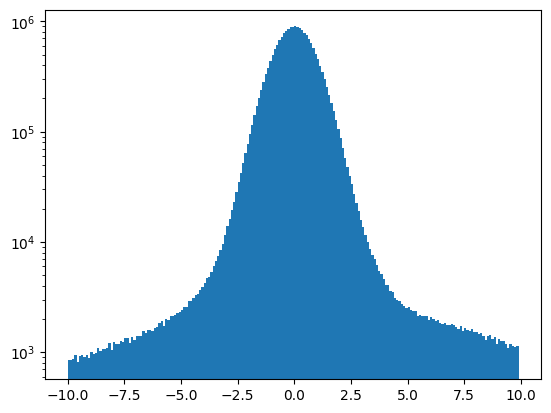

In [92]:
plt.hist(d,bins=np.arange(-10,10,0.1))
plt.yscale('log')


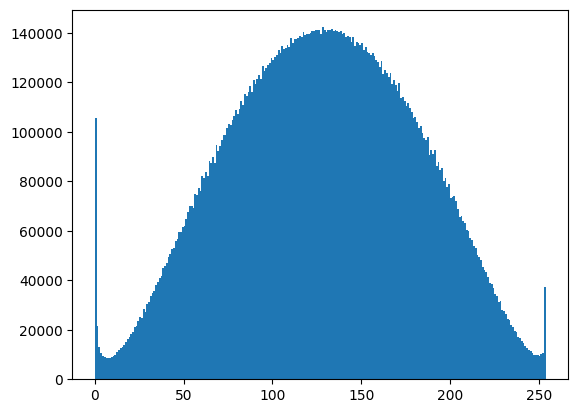

In [113]:
d2=np.round((np.tanh(d/2)+1)*255/2).astype(np.uint8)

plt.hist(d2,bins=np.arange(0,255,1));
# plt.yscale('log')

In [77]:
np.max(d2)

254

In [151]:
d2=np.round((np.tanh(d/2)+1)*255/2).astype(np.uint8)

d3=d2.astype(np.float32)*2/255-1

d3=np.arctanh(d3*0.99)*2/0.99

e=np.percentile(np.abs(d3-d),95)
print(e)

0.024228453636169434


In [146]:
np.percentile(d,99)

3.990234375

In [115]:
d3.min()

-9.903272

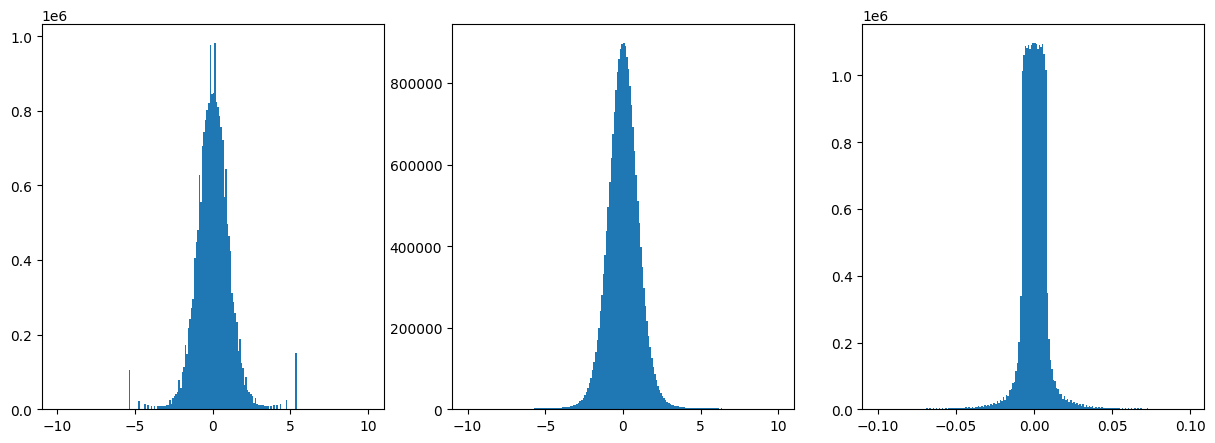

In [128]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(d3,bins=np.arange(-10,10.1,0.1));
plt.subplot(1,3,2)
plt.hist(d,bins=np.arange(-10,10.1,0.1));
plt.subplot(1,3,3)
plt.hist(d-d3,bins=np.arange(-0.1,0.1,0.001));



In [9]:
output.shape

torch.Size([10, 1025, 256000])

In [7]:
s = "Rome is the capital city of Italy. It is also the capital of the Lazio region, the centre of the Metropolitan City of Rome Capital, and a special comune (municipality) named Comune di Roma Capitale. With 2,860,009 residents in 1,285 km2, Rome is the country's most populated comune and the third most populous city in the European Union by population within city limits. The Metropolitan City of Rome, with a population of 4,355,725 residents, is the most populous metropolitan city in Italy. Its metropolitan area is the third-most populous within Italy. Rome is located in the central-western portion of the Italian Peninsula, within Lazio (Latium), along the shores of the Tiber."*8
batch = tokenizer(s, max_length=1024, padding='max_length', truncation=True)
batch['input_ids']=torch.tensor(batch['input_ids'])

In [8]:
batch['input_ids'].shape

torch.Size([1024])

In [9]:
input_ids = batch['input_ids'].to(gemma7.device)
labels = input_ids[..., 1:].cpu().clone().detach().cpu()

In [14]:
input_ids

tensor([     2,  52738,    603,  ...,  13058,    575, 235248], device='cuda:0')

In [25]:
with torch.no_grad():
    output = gemma7(input_ids.unsqueeze(0),return_dict=True,use_cache=False,output_hidden_states=False)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

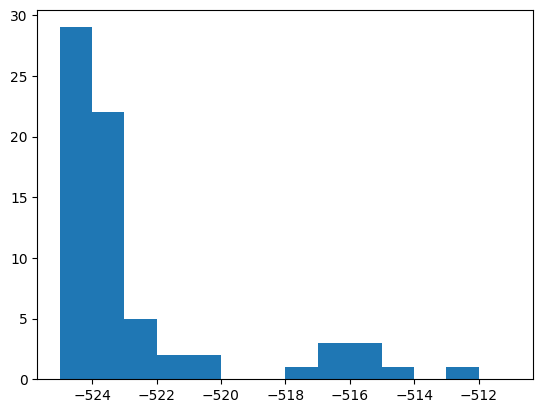

In [140]:

plt.hist(output['logits'][0,60].cpu().detach().numpy(), bins=np.arange(-525,-510));

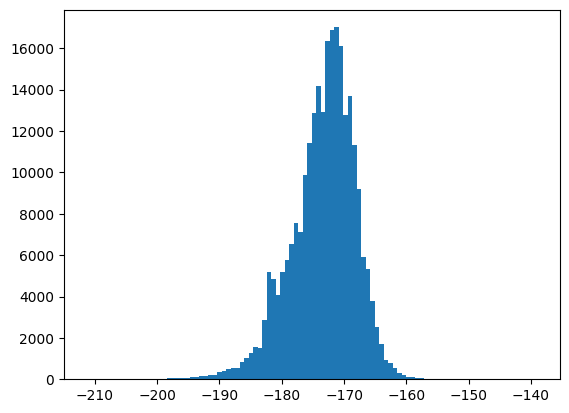

In [52]:
plt.hist(output['logits'][0,800].cpu().detach().numpy(), bins=100);

In [73]:
sort_results = torch.topk(output['logits'], 10, dim=-1).indices

In [74]:
tokenizer.convert_ids_to_tokens(input_ids[101:102] )

['▁']

In [75]:
sort_results[0, 100, :] 

tensor([235248,   1163,   1105,    978,   2449,  10686,   4461,   8167,   1317,
         25256], device='cuda:0')

In [76]:
sort_results[0, 100, :] == input_ids[101] 

tensor([ True, False, False, False, False, False, False, False, False, False],
       device='cuda:0')

In [77]:
tokenizer.convert_ids_to_tokens(sort_results[0,100,:])

['▁',
 '▁over',
 '▁about',
 '▁more',
 '▁around',
 '▁approximately',
 '▁almost',
 '▁nearly',
 '▁just',
 '▁roughly']

In [59]:
tokenizer.convert_ids_to_tokens(input_ids[95:105])

['▁Rome', ',', '▁with', '▁a', '▁population', '▁of', '▁', '4', ',', '3']

In [78]:
logits = output['logits']

In [86]:
sort_results[0,100]

tensor([235248,   1163,   1105,    978,   2449,  10686,   4461,   8167,   1317,
         25256], device='cuda:0')

In [87]:
logits[0, 100][sort_results[0,100]]

tensor([103.5000, 101.2500, 100.5625, 100.5000, 100.0000,  99.8750,  99.6875,
         99.5000,  97.9375,  97.9375], device='cuda:0')

In [90]:
logits[torch.arange(1).reshape(1,1,1), torch.arange(1024).reshape(1,1024,1), sort_results][0,100]

tensor([103.5000, 101.2500, 100.5625, 100.5000, 100.0000,  99.8750,  99.6875,
         99.5000,  97.9375,  97.9375], device='cuda:0')

In [92]:
with torch.no_grad():
    output2 = gemma2(input_ids.unsqueeze(0).to(gemma2.device),return_dict=True,use_cache=False,output_hidden_states=False)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

In [117]:
output3 = gemma2.model(input_ids.unsqueeze(0).to(gemma2.device), return_dict=True,use_cache=False,output_hidden_states=False)

In [121]:
(gemma2.lm_head(output3['last_hidden_state']) == gemma2(input_ids.unsqueeze(0).to(gemma2.device), return_dict=True,use_cache=False,output_hidden_states=False)['logits']).all()

tensor(True, device='cuda:2')

In [93]:
logits2 = output2['logits']

In [95]:
logits2[0,100][sort_results[0,100].cpu()]

tensor([ -9.0469, -11.6562, -12.2969, -12.5859, -12.7500, -12.5391, -14.2422,
        -13.6016, -14.7500, -14.7188], device='cuda:2')

In [99]:
sort_results2 = torch.topk(logits2, 10, dim=-1).indices
logits2[0,100][sort_results2[0,100]]

tensor([ -9.0469, -11.6562, -12.2969, -12.5391, -12.5859, -12.7500, -13.6016,
        -14.2422, -14.7188, -14.7500], device='cuda:2')

In [100]:
tokenizer.convert_ids_to_tokens(sort_results2[0,100])

['▁',
 '▁over',
 '▁about',
 '▁approximately',
 '▁more',
 '▁around',
 '▁nearly',
 '▁almost',
 '▁roughly',
 '▁just']

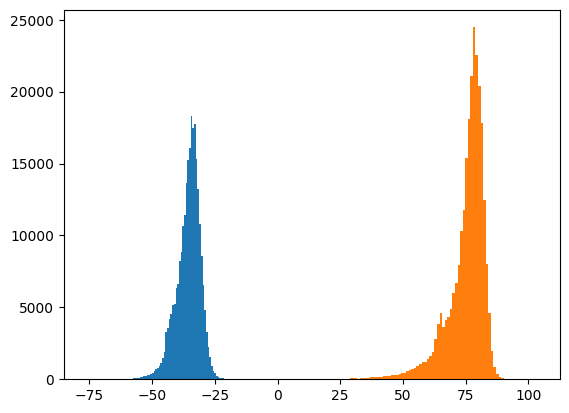

In [98]:
plt.hist(logits2[0,100].cpu().detach().numpy(), bins=100);
plt.hist(logits[0,100].cpu().detach().numpy(), bins=100);